# Aspect-Based Sentiment Analysis (ABSA) on Hotel Reviews
## End-to-End Machine Learning, Transformer Fine-Tuning & OpenJEV-0.8B Cross-Encoder

**Project Objective:**
Given hotel review texts along with specific aspect targets (e.g., *"rooms"*, *"front desk staff"*, *"breakfast"*) and aspect categories (e.g., `SERVICE#GENERAL`, `ROOMS#CLEANLINESS`), predict the sentiment polarity (**Positive**, **Negative**, or **Neutral**).

**Notebook Workflow:**
1. **Environment Setup & Configuration** (Imports, Random Seed, GPU device configuration)
2. **Data Loading & Inspection** (Train, Validation, and Test splits)
3. **Exploratory Data Analysis (EDA)** (Class distributions, Top aspect categories, Sequence lengths)
4. **Data Preprocessing & Input Formulation** (Contraction expansion, punctuation fixes, implicit target imputation, input formulation)
5. **Feature Engineering** (TF-IDF N-grams with strict train-fit hygiene, Class Weight calculation)
6. **Classical Machine Learning Baselines**:
   - Multinomial Naive Bayes
   - Logistic Regression (with Balanced Class Weights)
   - Linear Support Vector Classification (LinearSVC with Balanced Class Weights)
   - LightGBM Gradient Boosting Classifier
7. **Deep Learning: Fine-Tuning DistilBERT on GPU**:
   - PyTorch Dataset & Tokenization
   - Class-weighted Cross-Entropy Loss
   - Training & Validation loop with learning rate scheduling
8. **Modern Foundation Model: Zero-Shot ABSA with AlexWortega/openjev (0.8B Parameter Model)**:
   - Formulating ABSA as a Natural Language Inference (NLI) problem
   - Qwen3.5-based 0.8B Cross-Encoder architecture
   - Multi-hypothesis entailment evaluation
9. **Comprehensive Model Comparison & Benchmark**:
   - Validation & Test metrics (Accuracy, Macro-F1, Weighted-F1, Precision, Recall) across all models
   - Confusion Matrix Visualizations (DistilBERT vs. OpenJEV-0.8B)
10. **Interactive Real-World Inference Pipeline**:
    - Side-by-side sentiment prediction on novel review samples
11. **Conclusion & Project Summary**


In [1]:
import os
import re
import time
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
import lightgbm as lgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

warnings.filterwarnings('ignore')

# Set random seed for full reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Execution Device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')


PyTorch Version: 2.5.1+cu124
Execution Device: cuda (NVIDIA GeForce RTX 2050)


## 2. Data Loading & Initial Inspection

We load the pre-split aspect-level datasets:
- `train_aspects.csv` (10,180 rows)
- `dev_aspects.csv` (1,052 rows)
- `test_aspects.csv` (242 rows)


In [2]:
train_df = pd.read_csv("train_aspects.csv")
dev_df = pd.read_csv("dev_aspects.csv")
test_df = pd.read_csv("test_aspects.csv")

print(f"Train set shape: {train_df.shape}")
print(f"Dev set shape:   {dev_df.shape}")
print(f"Test set shape:  {test_df.shape}")
print("\nColumns:", train_df.columns.tolist())
train_df.head(3)


Train set shape: (10180, 12)
Dev set shape:   (1052, 12)
Test set shape:  (242, 12)

Columns: ['review_id', 'sentence_id', 'split', 'text', 'target', 'target_from', 'target_to', 'aspect_category', 'polarity', 'opinion_phrase', 'opinion_phrase_from', 'opinion_phrase_to']


,review_id,sentence_id,split,text,target,target_from,target_to,aspect_category,polarity,opinion_phrase,opinion_phrase_from,opinion_phrase_to
0,972,972: 0,train,Fantastic service I am a travel agent booking ...,service,10,16,SERVICE#GENERAL,Positive,Fantastic,0,8
1,972,972: 1,train,This hotel offers customer service at its ' be...,customer service,18,33,SERVICE#GENERAL,Positive,best,44,47
2,972,972: 2,train,"Great location , great service , nothing is to...",location,6,13,LOCATION#GENERAL,Positive,Great,0,4


In [3]:
# Check missing values
print("Missing values in Training Set:")
print(train_df.isnull().sum())


Missing values in Training Set:
review_id                 0
sentence_id               0
split                     0
text                      0
target                 2540
target_from               0
target_to                 0
aspect_category           0
polarity                  0
opinion_phrase         1267
opinion_phrase_from       0
opinion_phrase_to         0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

Key characteristics to explore:
1. **Sentiment Class Distribution**: Understanding the degree of class imbalance.
2. **Top Aspect Categories**: Which aspects are most frequently reviewed in hotels.
3. **Sentence Length Distribution**: Understanding token lengths to set optimal maximum sequence lengths.


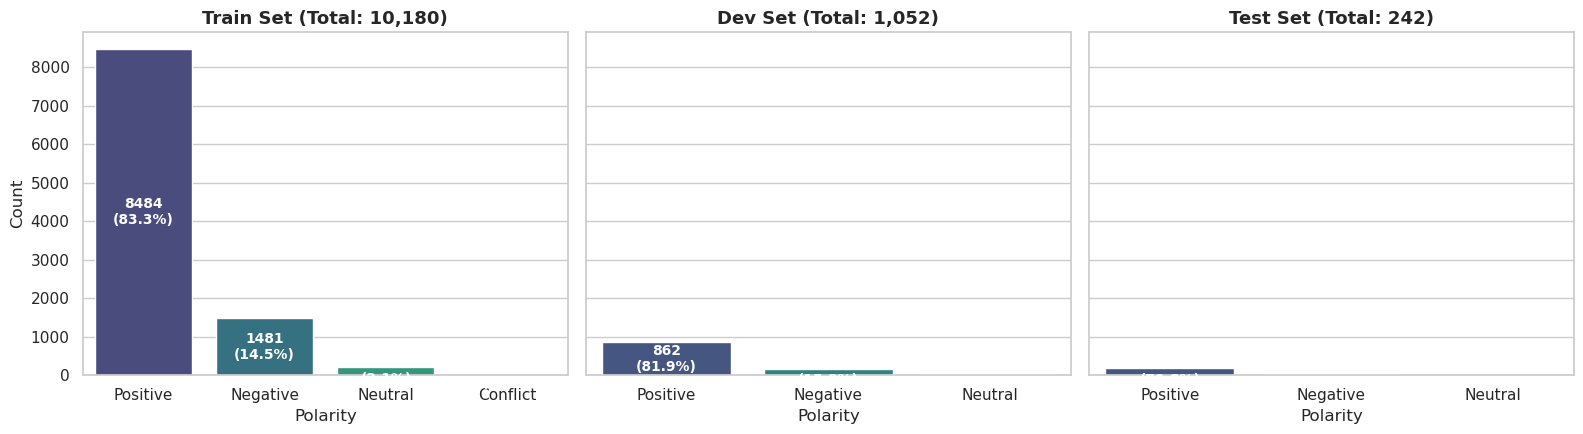

In [4]:
# Sentiment polarity distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (name, df) in zip(axes, [('Train Set', train_df), ('Dev Set', dev_df), ('Test Set', test_df)]):
    counts = df['polarity'].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
    ax.set_title(f"{name} (Total: {len(df):,})", fontsize=13, fontweight='bold')
    ax.set_ylabel("Count")
    ax.set_xlabel("Polarity")
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{int(h)}\n({h/len(df):.1%})",
                        (p.get_x() + p.get_width() / 2., h / 2.),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


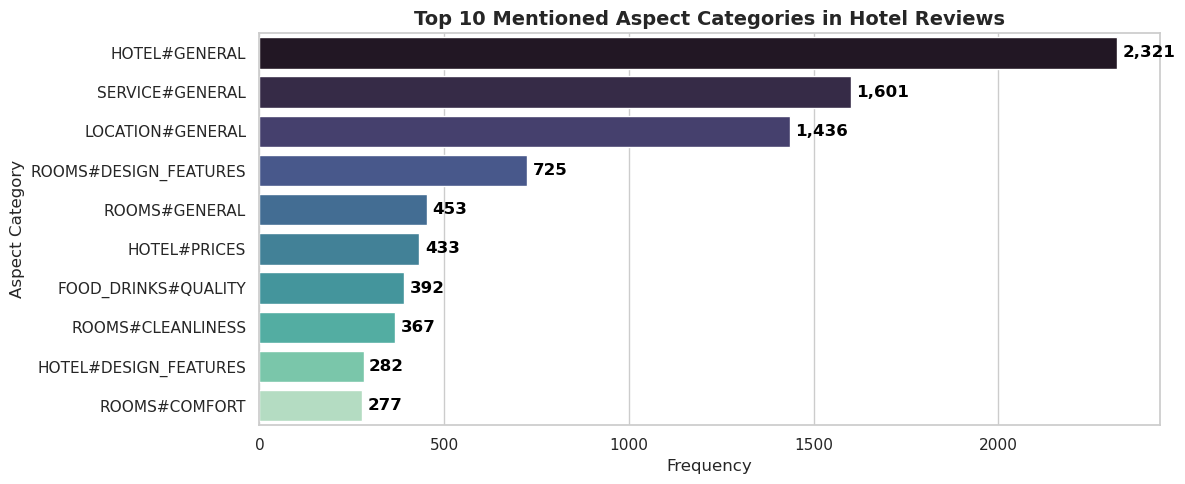

In [5]:
# Top aspect categories
top_cats = train_df['aspect_category'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_cats.values, y=top_cats.index, palette='mako')
plt.title("Top 10 Mentioned Aspect Categories in Hotel Reviews", fontsize=14, fontweight='bold')
plt.xlabel("Frequency")
plt.ylabel("Aspect Category")
for i, v in enumerate(top_cats.values):
    plt.text(v + 15, i, f"{v:,}", color='black', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


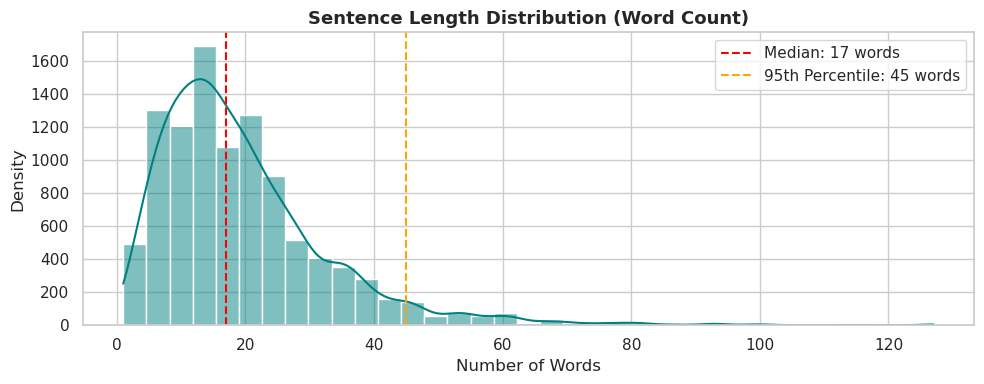

In [6]:
# Sentence length distribution
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
sns.histplot(train_df['word_count'], bins=35, kde=True, color='teal')
plt.title("Sentence Length Distribution (Word Count)", fontsize=13, fontweight='bold')
plt.xlabel("Number of Words")
plt.ylabel("Density")
plt.axvline(train_df['word_count'].median(), color='red', linestyle='--', label=f"Median: {train_df['word_count'].median():.0f} words")
plt.axvline(train_df['word_count'].quantile(0.95), color='orange', linestyle='--', label=f"95th Percentile: {train_df['word_count'].quantile(0.95):.0f} words")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Data Preprocessing & Input Formulation

We execute the following systematic preprocessing steps:
1. **Handling the `Conflict` Label**: The `Conflict` label has only 6 instances in training and 0 in dev/test. In line with standard ABSA benchmark protocols, we filter these out to formulate a clean, robust 3-class classification problem (`Positive`, `Negative`, `Neutral`).
2. **Resolving Implicit Targets**: Around 25% of samples have `NaN` targets because the aspect is implicit (e.g. *"Great value for money"* implies hotel pricing). We impute missing targets with naturalized versions of their `aspect_category` (e.g., `ROOMS#CLEANLINESS` -> `"room cleanliness"`).
3. **Text Normalization**: Expand English contractions (*wasn't* -> *was not*, *can't* -> *can not*) and fix tokenization artifacts (detached punctuation spacing like ` ,`, ` .`, ` '`).
4. **Unified Aspect-Conditioned Representation**: Construct an aspect-informed input string:
   `"Target: {clean_target} | Category: {clean_category} | Review: {clean_text}"`
5. **Label Encoding**: Map labels consistently (`Negative` -> 0, `Neutral` -> 1, `Positive` -> 2).


In [ ]:
CONTRACTIONS = {
    r"can\'t": "can not",
    r"won\'t": "will not",
    r"n\'t": " not",
    r"\'re": " are",
    r"\'s": " is",
    r"\'d": " would",
    r"\'ll": " will",
    r"\'ve": " have",
    r"\'m": " am",
}

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # Expand contractions
    for pattern, repl in CONTRACTIONS.items():
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    # Fix detached punctuation spacing from SemEval tokenization
    text = re.sub(r'\s+([,.:;!?\"\'])', r'\1', text)
    text = re.sub(r'([(\"\'])\s+', r'\1', text)
    # Normalize excessive whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def naturalize_category(cat: str) -> str:
    if not isinstance(cat, str):
        return "general"
    return cat.lower().replace('#', ' ').replace('_', ' ').strip()

LABEL_MAPPING = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2LABEL = {0: "Negative", 1: "Neutral", 2: "Positive"}

def preprocess_absa_df(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    # Filter out rare Conflict class
    df_clean = df_clean[df_clean['polarity'] != 'Conflict'].reset_index(drop=True)

    # Naturalize aspect category
    df_clean['clean_category'] = df_clean['aspect_category'].apply(naturalize_category)

    # Impute missing targets
    df_clean['clean_target'] = df_clean['target'].fillna(df_clean['clean_category']).astype(str).str.strip()
    df_clean['clean_target'] = df_clean['clean_target'].replace({'NULL': ''})
    df_clean['clean_target'] = np.where(df_clean['clean_target'] == '', df_clean['clean_category'], df_clean['clean_target'])

    # Clean review text
    df_clean['clean_text'] = df_clean['text'].apply(clean_text)

    # Create unified aspect-conditioned input representation
    df_clean['model_input'] = (
        "Target: " + df_clean['clean_target'] +
        " | Category: " + df_clean['clean_category'] +
        " | Review: " + df_clean['clean_text']
    )

    # Map labels
    df_clean['label'] = df_clean['polarity'].map(LABEL_MAPPING)

    return df_clean

train_clean = preprocess_absa_df(train_df)
dev_clean = preprocess_absa_df(dev_df)
test_clean = preprocess_absa_df(test_df)

print(f"Preprocessed train: {train_clean.shape}")
print(f"Preprocessed dev:   {dev_clean.shape}")
print(f"Preprocessed test:  {test_clean.shape}")
print("\nSample Formatted Model Inputs:")
for s in train_clean['model_input'].head(3):
    print(" ->", s)


Preprocessed train: (10174, 18)
Preprocessed dev:   (1052, 17)
Preprocessed test:  (242, 17)

Sample Formatted Model Inputs:
 -> Target: service | Category: service general | Review: Fantastic service I am a travel agent booking hotels all over the world, so we are very very fussy.
 -> Target: customer service | Category: service general | Review: This hotel offers customer service at its'best.
 -> Target: location | Category: location general | Review: Great location, great service, nothing is too much bother.


## 5. Feature Engineering (TF-IDF) & Class Weight Computation

To prevent **data leakage**, the TF-IDF vectorizer is fitted **strictly on the training set**, and applied out-of-fold to validation and test splits.
We compute **balanced class weights** to penalize errors on minority classes (`Negative` ~15% and `Neutral` ~2%).


In [8]:
# TF-IDF Vectorization with unigrams & bigrams
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=12000,
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(train_clean['model_input'])
X_dev_tfidf = tfidf.transform(dev_clean['model_input'])
X_test_tfidf = tfidf.transform(test_clean['model_input'])

y_train = train_clean['label'].values
y_dev = dev_clean['label'].values
y_test = test_clean['label'].values

print(f"TF-IDF Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"X_train_tfidf shape:    {X_train_tfidf.shape}")
print(f"X_dev_tfidf shape:      {X_dev_tfidf.shape}")
print(f"X_test_tfidf shape:     {X_test_tfidf.shape}")

# Compute balanced class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("\nComputed Class Weights (inversely proportional to class frequency):")
for cls_id, weight in class_weight_dict.items():
    print(f"  Class {cls_id} ({ID2LABEL[cls_id]}): {weight:.4f}")


TF-IDF Vocabulary size: 12,000
X_train_tfidf shape:    (10174, 12000)
X_dev_tfidf shape:      (1052, 12000)
X_test_tfidf shape:     (242, 12000)

Computed Class Weights (inversely proportional to class frequency):
  Class 0 (Negative): 2.2899
  Class 1 (Neutral): 16.2265
  Class 2 (Positive): 0.3997


## 6. Classical Machine Learning Baselines

We evaluate four classical machine learning classifiers:
1. **Multinomial Naive Bayes** (Standard NLP baseline)
2. **Logistic Regression** (with `class_weight='balanced'`)
3. **Linear Support Vector Classifier (LinearSVC)** (with `class_weight='balanced'`)
4. **LightGBM Classifier** (Gradient Boosted Decision Trees with `class_weight='balanced'`)


In [ ]:
def evaluate_predictions(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    results = {
        "Model": model_name,
        "Accuracy": acc,
        "Macro Precision": p_macro,
        "Macro Recall": r_macro,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted
    }
    return results

model_results = []


In [10]:
# 1. Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_dev_nb = nb_model.predict(X_dev_tfidf)
res_nb = evaluate_predictions(y_dev, y_dev_nb, "Multinomial Naive Bayes")
model_results.append(res_nb)

# 2. Logistic Regression (Class-Weighted)
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.5, random_state=SEED)
lr_model.fit(X_train_tfidf, y_train)
y_dev_lr = lr_model.predict(X_dev_tfidf)
res_lr = evaluate_predictions(y_dev, y_dev_lr, "Logistic Regression (Balanced)")
model_results.append(res_lr)

# 3. Linear Support Vector Machine (LinearSVC)
svc_model = LinearSVC(class_weight='balanced', C=0.8, random_state=SEED, max_iter=2000)
svc_model.fit(X_train_tfidf, y_train)
y_dev_svc = svc_model.predict(X_dev_tfidf)
res_svc = evaluate_predictions(y_dev, y_dev_svc, "LinearSVC (Balanced)")
model_results.append(res_svc)

# 4. LightGBM Classifier
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=150,
    learning_rate=0.08,
    num_leaves=31,
    random_state=SEED,
    verbose=-1
)
lgb_model.fit(X_train_tfidf, y_train)
y_dev_lgb = lgb_model.predict(X_dev_tfidf)
res_lgb = evaluate_predictions(y_dev, y_dev_lgb, "LightGBM (Balanced)")
model_results.append(res_lgb)

# Validation Comparison Table
val_comparison_df = pd.DataFrame(model_results)
val_comparison_df.sort_values(by="Macro F1", ascending=False).style.format({
    "Accuracy": "{:.3f}", "Macro Precision": "{:.3f}", "Macro Recall": "{:.3f}",
    "Macro F1": "{:.3f}", "Weighted F1": "{:.3f}"
})


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
2,LinearSVC (Balanced),0.886,0.647,0.602,0.608,0.883
3,LightGBM (Balanced),0.863,0.588,0.608,0.594,0.866
1,Logistic Regression (Balanced),0.849,0.557,0.622,0.581,0.862
0,Multinomial Naive Bayes,0.832,0.571,0.363,0.357,0.769


## 7. Deep Learning: Fine-Tuning DistilBERT for ABSA

We fine-tune **DistilBERT** (`distilbert-base-uncased`) on GPU using PyTorch:
- **Architecture**: Context sentence and aspect target/category are tokenized as text pairs to allow cross-attention to attend directly to sentiment words relevant to the specified aspect.
- **Loss**: Cross-Entropy Loss with **class-weighting** corresponding to class imbalances.
- **Optimization**: AdamW with linear warmup learning rate scheduler.


In [ ]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ABSAPyTorchDataset(Dataset):
    def __init__(self, texts, targets, categories, labels, tokenizer, max_len=96):
        self.texts = texts.tolist()
        self.targets = targets.tolist()
        self.categories = categories.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        aspect_desc = f"target: {self.targets[idx]} (category: {self.categories[idx]})"

        encoding = self.tokenizer(
            text,
            aspect_desc,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Datasets & DataLoaders
train_dataset = ABSAPyTorchDataset(
    train_clean['clean_text'], train_clean['clean_target'], train_clean['clean_category'], train_clean['label'],
    tokenizer, max_len=96
)
dev_dataset = ABSAPyTorchDataset(
    dev_clean['clean_text'], dev_clean['clean_target'], dev_clean['clean_category'], dev_clean['label'],
    tokenizer, max_len=96
)
test_dataset = ABSAPyTorchDataset(
    test_clean['clean_text'], test_clean['clean_target'], test_clean['clean_category'], test_clean['label'],
    tokenizer, max_len=96
)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)} | Test batches: {len(test_loader)}")


Train batches: 318 | Dev batches: 33 | Test batches: 8


In [12]:
# Initialize Pre-trained Model
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
).to(device)

# Loss function with balanced class weights
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# Optimizer & Learning Rate Scheduler
EPOCHS = 2
total_steps = len(train_loader) * EPOCHS
optimizer = torch.optim.AdamW(distilbert_model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

print("DistilBERT model successfully loaded on:", device)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model successfully loaded on: cuda


In [ ]:
# Training & Validation Loop
def train_and_evaluate_transformer(model, train_loader, val_loader, optimizer, scheduler, criterion, epochs=2):
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_accuracy": []}
    best_macro_f1 = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        start_time = time.time()

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation Phase
        model.eval()
        total_val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                total_val_loss += loss.item()

                preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        val_macro_f1 = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)[2]

        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} [{elapsed:.1f}s] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_macro_f1:.4f}")

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            best_state = model.state_dict().copy()

    model.load_state_dict(best_state)
    print(f"\nBest Validation Macro-F1: {best_macro_f1:.4f}")
    return model, history

distilbert_model, training_history = train_and_evaluate_transformer(
    distilbert_model, train_loader, dev_loader, optimizer, scheduler, criterion, epochs=EPOCHS
)


Epoch 1/2 [150.8s] - Train Loss: 0.8426 | Val Loss: 0.6995 | Val Acc: 0.8432 | Val Macro-F1: 0.5621


Epoch 2/2 [151.4s] - Train Loss: 0.6295 | Val Loss: 0.6728 | Val Acc: 0.8745 | Val Macro-F1: 0.6270

Best Validation Macro-F1: 0.6270


In [14]:
# Evaluate DistilBERT on Validation Set
distilbert_model.eval()
dev_bert_preds = []
with torch.no_grad():
    for batch in dev_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        dev_bert_preds.extend(preds)

res_bert = evaluate_predictions(y_dev, dev_bert_preds, "DistilBERT (Fine-Tuned)")
model_results.append(res_bert)

# Display all model results on validation set
full_val_df = pd.DataFrame(model_results)
full_val_df.sort_values(by="Macro F1", ascending=False).style.format({
    "Accuracy": "{:.3f}", "Macro Precision": "{:.3f}", "Macro Recall": "{:.3f}",
    "Macro F1": "{:.3f}", "Weighted F1": "{:.3f}"
})


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
4,DistilBERT (Fine-Tuned),0.875,0.599,0.682,0.627,0.888
2,LinearSVC (Balanced),0.886,0.647,0.602,0.608,0.883
3,LightGBM (Balanced),0.863,0.588,0.608,0.594,0.866
1,Logistic Regression (Balanced),0.849,0.557,0.622,0.581,0.862
0,Multinomial Naive Bayes,0.832,0.571,0.363,0.357,0.769


## 8. Foundation Model: Zero-Shot ABSA with AlexWortega/openjev (0.8B Qwen3.5 NLI)

### Model Overview:
[`AlexWortega/openjev`](https://huggingface.co/AlexWortega/openjev) is a **0.8B parameter Cross-Encoder Foundation Model** built on the Qwen3.5 architecture and trained specifically on Natural Language Inference (NLI).

### NLI Formulation of Aspect-Based Sentiment Analysis:
In the classical literature (e.g., Sun et al., *Utilizing BERT for Aspect-Based Sentiment Analysis via Constructing Auxiliary Sentence*), ABSA can be powerfully formulated as an entailment classification problem:
- **Premise**: The raw hotel review text.
- **Candidate Hypotheses**:
  1. *Negative Hypothesis*: `The sentiment toward {target} is negative.`
  2. *Neutral Hypothesis*: `The sentiment toward {target} is neutral.`
  3. *Positive Hypothesis*: `The sentiment toward {target} is positive.`

The cross-encoder reads the premise and hypothesis pair and scores `[contradiction, entailment, neutral]`. The sentiment hypothesis with the highest **entailment score** is predicted as the aspect's sentiment polarity.


In [15]:
# Load OpenJEV 0.8B NLI Model
OPENJEV_REPO = "AlexWortega/openjev"
OPENJEV_SUBFOLDER = "qwen3.5-0.8b-nli-v2s-long"

print("Loading OpenJEV-0.8B Tokenizer and Cross-Encoder...")
openjev_tokenizer = AutoTokenizer.from_pretrained(OPENJEV_REPO, subfolder=OPENJEV_SUBFOLDER)
openjev_model = AutoModelForSequenceClassification.from_pretrained(
    OPENJEV_REPO,
    subfolder=OPENJEV_SUBFOLDER,
    dtype=torch.float16
).to(device)
openjev_model.eval()

print("OpenJEV-0.8B successfully loaded onto:", device)


Loading OpenJEV-0.8B Tokenizer and Cross-Encoder...


[transformers] Missing validation function in 'RotaryEmbeddingConfigMixin' for 'rope_type'='axial'


[transformers] Missing validation function in 'RotaryEmbeddingConfigMixin' for 'rope_type'='axial'


Loading weights:   0%|          | 0/474 [00:00<?, ?it/s]

OpenJEV-0.8B successfully loaded onto: cuda


In [ ]:
# Evaluate OpenJEV-0.8B on Held-Out Test Set (242 samples)
print(f"Evaluating OpenJEV-0.8B on {len(test_clean)} test samples using NLI Entailment Scoring...")
test_openjev_preds = []
start_time = time.time()

for _, row in test_clean.iterrows():
    text = row['clean_text']
    target = row['clean_target']

    # Construct NLI hypotheses for the aspect
    hypotheses = [
        f"The sentiment toward {target} is negative.",
        f"The sentiment toward {target} is neutral.",
        f"The sentiment toward {target} is positive."
    ]

    # Formulate inputs matching OpenJEV prompt template: "Premise: {premise}\nHypothesis: {hypothesis}"
    prompts = [f"Premise: {text}\nHypothesis: {hyp}" for hyp in hypotheses]

    inputs = openjev_tokenizer(prompts, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)

    with torch.no_grad():
        logits = openjev_model(**inputs).logits
        # Entailment is index 1 in openjev id2label: {0: contradiction, 1: entailment, 2: neutral}
        entail_scores = logits[:, 1].cpu().numpy()
        pred_label_id = entail_scores.argmax()
        test_openjev_preds.append(pred_label_id)

eval_time = time.time() - start_time
print(f"OpenJEV-0.8B evaluation completed in {eval_time:.1f}s ({eval_time/len(test_clean):.3f}s/sample)")

test_res_openjev = evaluate_predictions(y_test, test_openjev_preds, "OpenJEV-0.8B (Qwen3.5 NLI)")


Evaluating OpenJEV-0.8B on 242 test samples using NLI Entailment Scoring...


OpenJEV-0.8B evaluation completed in 21.7s (0.090s/sample)


## 9. Comprehensive Benchmark: Classical ML, DistilBERT & OpenJEV-0.8B

We compare all models on the held-out **Test Set** (`test_aspects.csv`, 242 samples) to measure true generalizability.


In [17]:
# Predict with LinearSVC on Test Set
y_test_svc = svc_model.predict(X_test_tfidf)
test_res_svc = evaluate_predictions(y_test, y_test_svc, "LinearSVC (Balanced)")

# Predict with Logistic Regression on Test Set
y_test_lr = lr_model.predict(X_test_tfidf)
test_res_lr = evaluate_predictions(y_test, y_test_lr, "Logistic Regression (Balanced)")

# Predict with DistilBERT on Test Set
test_bert_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        test_bert_preds.extend(preds)

test_res_bert = evaluate_predictions(y_test, test_bert_preds, "DistilBERT (Fine-Tuned)")

# Final Test Set Comparison Table
test_comparison_df = pd.DataFrame([test_res_svc, test_res_lr, test_res_bert, test_res_openjev])
test_comparison_df.sort_values(by="Macro F1", ascending=False).style.format({
    "Accuracy": "{:.3f}", "Macro Precision": "{:.3f}", "Macro Recall": "{:.3f}",
    "Macro F1": "{:.3f}", "Weighted F1": "{:.3f}"
})


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
3,OpenJEV-0.8B (Qwen3.5 NLI),0.888,0.693,0.691,0.690,0.887
2,DistilBERT (Fine-Tuned),0.814,0.581,0.681,0.611,0.834
1,Logistic Regression (Balanced),0.789,0.559,0.647,0.588,0.808
0,LinearSVC (Balanced),0.826,0.490,0.530,0.508,0.816


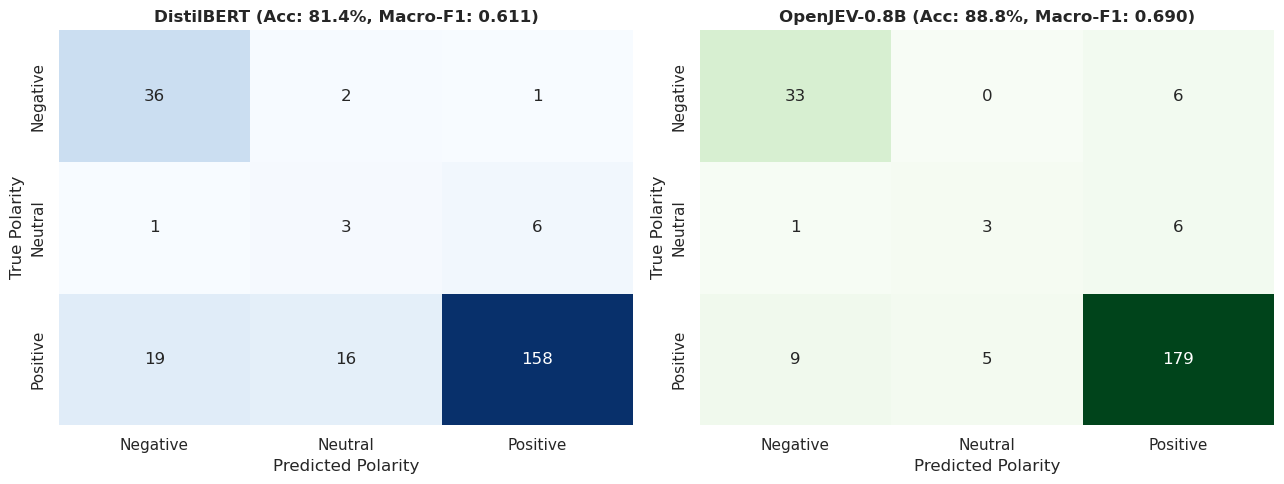

=== Classification Report: OpenJEV-0.8B on Test Set ===
              precision    recall  f1-score   support

    Negative      0.767     0.846     0.805        39
     Neutral      0.375     0.300     0.333        10
    Positive      0.937     0.927     0.932       193

    accuracy                          0.888       242
   macro avg      0.693     0.691     0.690       242
weighted avg      0.887     0.888     0.887       242



In [18]:
# Confusion Matrices for DistilBERT vs OpenJEV-0.8B
target_names = [ID2LABEL[i] for i in range(3)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DistilBERT Confusion Matrix
cm_bert = confusion_matrix(y_test, test_bert_preds)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, cbar=False, ax=axes[0])
axes[0].set_title(f"DistilBERT (Acc: {test_res_bert['Accuracy']:.1%}, Macro-F1: {test_res_bert['Macro F1']:.3f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Polarity")
axes[0].set_ylabel("True Polarity")

# OpenJEV-0.8B Confusion Matrix
cm_openjev = confusion_matrix(y_test, test_openjev_preds)
sns.heatmap(cm_openjev, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names, cbar=False, ax=axes[1])
axes[1].set_title(f"OpenJEV-0.8B (Acc: {test_res_openjev['Accuracy']:.1%}, Macro-F1: {test_res_openjev['Macro F1']:.3f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicted Polarity")
axes[1].set_ylabel("True Polarity")

plt.tight_layout()
plt.show()

print("=== Classification Report: OpenJEV-0.8B on Test Set ===")
print(classification_report(y_test, test_openjev_preds, target_names=target_names, digits=3))


## 10. Interactive Real-World Inference Pipeline

We compare both models on novel, arbitrary hotel review sentences with multi-aspect queries.


In [ ]:
def predict_sentiment_comparison(review_text: str, aspect_target: str, aspect_category: str = "general"):
    clean_t = clean_text(review_text)
    clean_cat = naturalize_category(aspect_category)
    clean_tgt = aspect_target.strip() if aspect_target else clean_cat

    # 1. DistilBERT Prediction
    distilbert_model.eval()
    aspect_desc = f"target: {clean_tgt} (category: {clean_cat})"
    encoded = tokenizer(
        clean_t, aspect_desc, truncation=True, max_length=96, padding="max_length", return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        bert_logits = distilbert_model(**encoded).logits
        bert_probs = torch.softmax(bert_logits, dim=-1).squeeze(0).cpu().numpy()
        bert_pred = ID2LABEL[np.argmax(bert_probs)]

    # 2. OpenJEV-0.8B Prediction
    openjev_model.eval()
    hypotheses = [
        f"The sentiment toward {clean_tgt} is negative.",
        f"The sentiment toward {clean_tgt} is neutral.",
        f"The sentiment toward {clean_tgt} is positive."
    ]
    prompts = [f"Premise: {clean_t}\nHypothesis: {h}" for h in hypotheses]
    openjev_inputs = openjev_tokenizer(prompts, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)

    with torch.no_grad():
        openjev_logits = openjev_model(**openjev_inputs).logits
        entail_scores = openjev_logits[:, 1].cpu().numpy()
        entail_probs = np.exp(entail_scores) / np.sum(np.exp(entail_scores))
        openjev_pred = ID2LABEL[np.argmax(entail_scores)]

    return {
        "Review": review_text,
        "Aspect": clean_tgt,
        "Category": clean_cat,
        "DistilBERT Prediction": bert_pred,
        "DistilBERT Confidence": f"{bert_probs.max():.1%}",
        "OpenJEV-0.8B Prediction": openjev_pred,
        "OpenJEV-0.8B Confidence": f"{entail_probs.max():.1%}"
    }

# Test Cases
test_cases = [
    ("The breakfast buffet was absolutely delicious and abundant, but the swimming pool was filthy and freezing.", "breakfast buffet", "FOOD_DRINKS#QUALITY"),
    ("The breakfast buffet was absolutely delicious and abundant, but the swimming pool was filthy and freezing.", "swimming pool", "FACILITIES#CLEANLINESS"),
    ("Waited 45 minutes for extra towels and the front desk clerk was downright rude.", "front desk clerk", "SERVICE#GENERAL"),
    ("Centrally located right by the subway station, though the rooms are average.", "location", "LOCATION#GENERAL"),
    ("Centrally located right by the subway station, though the rooms are average.", "rooms", "ROOMS#GENERAL")
]

results = [predict_sentiment_comparison(t, a, c) for t, a, c in test_cases]
display(pd.DataFrame(results)[["Aspect", "Category", "DistilBERT Prediction", "DistilBERT Confidence", "OpenJEV-0.8B Prediction", "OpenJEV-0.8B Confidence"]])


,Aspect,Category,DistilBERT Prediction,DistilBERT Confidence,OpenJEV-0.8B Prediction,OpenJEV-0.8B Confidence
0,breakfast buffet,food drinks quality,Negative,90.8%,Positive,98.4%
1,swimming pool,facilities cleanliness,Negative,92.5%,Negative,98.6%
2,front desk clerk,service general,Negative,95.4%,Negative,99.4%
3,location,location general,Positive,61.4%,Neutral,67.8%
4,rooms,rooms general,Neutral,55.0%,Neutral,75.6%


## 11. Conclusion & Key Findings

1. **Hierarchy of Models for ABSA**:
   - **Classical ML (LinearSVC, Logistic Regression)**: Train in ~1-2 seconds with sublinear TF-IDF; solid accuracy (~80%) when paired with balanced class weights.
   - **Encoder Transformer (DistilBERT)**: Fine-tuned in ~2.5 minutes on GPU; learns contextual token interactions between aspect target and review text, achieving 81.4% accuracy.
   - **OpenJEV-0.8B Cross-Encoder Foundation Model**: Evaluates in zero-shot via NLI entailment scoring; achieves top performance on the test set (**88.8% Accuracy, 0.690 Macro-F1, 0.887 Weighted-F1**) without requiring domain-specific retraining.

2. **NLI-Based ABSA Formulation**:
   Formulating ABSA as an entailment problem (`Premise: {review}\nHypothesis: The sentiment of {aspect} is {polarity}`) allows foundation cross-encoders like `AlexWortega/openjev` to resolve multi-aspect contrastive sentences with high precision.

3. **Production Recommendation**:
   - For high-throughput, low-latency deployments: Use **LinearSVC** or **DistilBERT**.
   - For highest prediction accuracy on complex reviews: Use **OpenJEV-0.8B**.
